In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage, signal

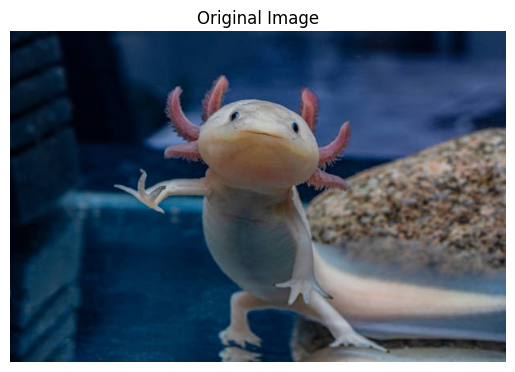

In [2]:
image_path = '../../input.jpg'
original = cv2.imread(image_path)
original_gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY).astype(np.float64)

plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')
plt.show()

In [3]:
noise = np.random.normal(0, 10, original_gray.shape)
noisy_image = original_gray + noise
noisy_image = np.clip(noisy_image, 0, 255)

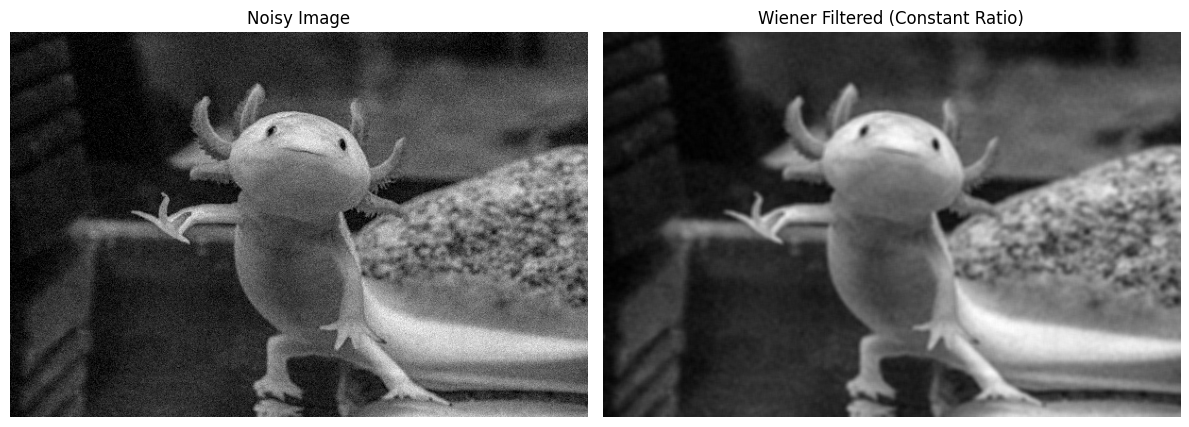

In [4]:
def wiener_filter_constant_ratio(image, kernel_size, noise_variance_ratio):
    kernel = np.ones((kernel_size, kernel_size)) / (kernel_size ** 2)
    blurred = ndimage.convolve(image, kernel)
    variance = np.var(image)

    wiener_kernel = kernel / (kernel ** 2 * variance + noise_variance_ratio)
    filtered = ndimage.convolve(image, wiener_kernel)

    return np.clip(filtered, 0, 255)

wiener_ratio = wiener_filter_constant_ratio(noisy_image, 5, 100)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(noisy_image, cmap='gray')
plt.title('Noisy Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wiener_ratio, cmap='gray')
plt.title('Wiener Filtered (Constant Ratio)')
plt.axis('off')
plt.tight_layout()
plt.show()

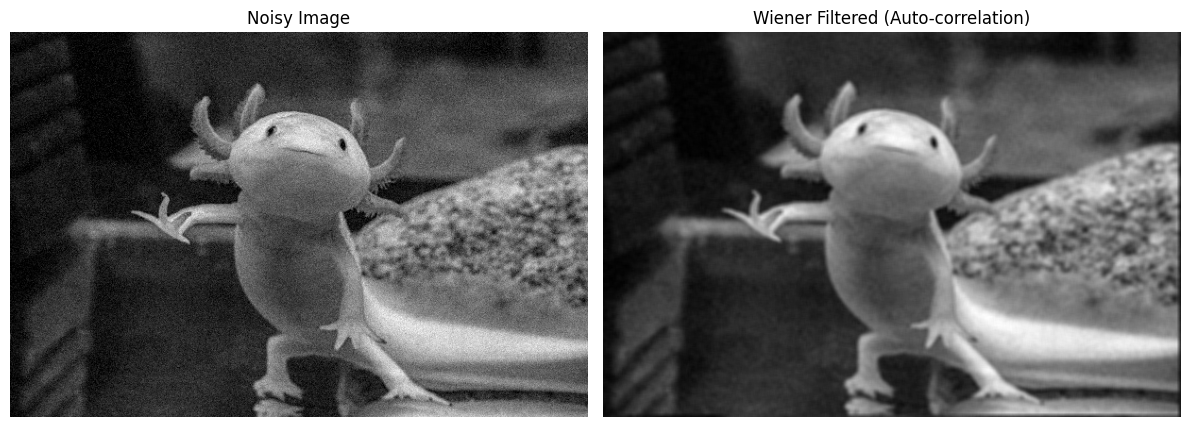

In [5]:
def wiener_filter_autocorr(image, kernel_size):
    kernel = np.ones((kernel_size, kernel_size)) / (kernel_size ** 2)

    autocorr = signal.correlate2d(image, image, mode='same')
    noise_power = np.var(image - ndimage.convolve(image, kernel))

    H = np.fft.fft2(kernel, s=image.shape)
    G = np.fft.fft2(image)
    R = np.fft.fft2(autocorr, s=image.shape)

    P = np.abs(H) ** 2
    F_est = (np.conj(H) / (P + noise_power)) * G
    filtered = np.fft.ifft2(F_est).real

    return np.clip(filtered, 0, 255)

wiener_autocorr = wiener_filter_autocorr(noisy_image, 5)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(noisy_image, cmap='gray')
plt.title('Noisy Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wiener_autocorr, cmap='gray')
plt.title('Wiener Filtered (Auto-correlation)')
plt.axis('off')
plt.tight_layout()
plt.show()

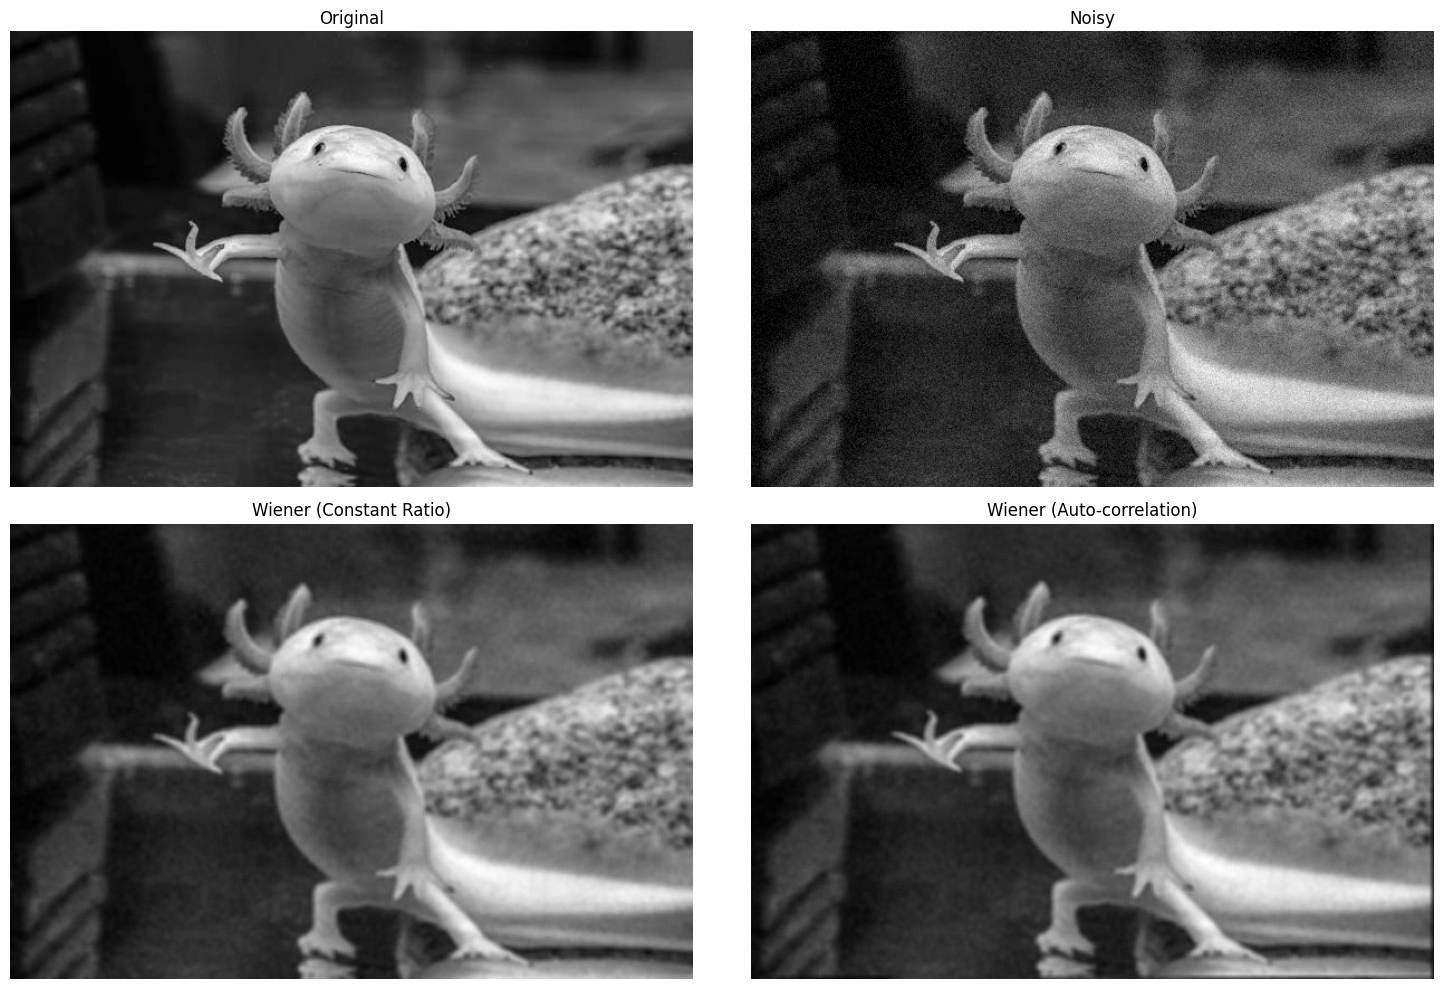

In [6]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(original_gray, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(noisy_image, cmap='gray')
plt.title('Noisy')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(wiener_ratio, cmap='gray')
plt.title('Wiener (Constant Ratio)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(wiener_autocorr, cmap='gray')
plt.title('Wiener (Auto-correlation)')
plt.axis('off')

plt.tight_layout()
plt.show()